# **Temporal Convolutional Network Baseline Physical Sensors**

## **Libraries Import**

In [1]:
from preprocessing import CMAPSS, preprocessing, create_windows
from Models import TCNRegressor
from Training import train
from Testing import test
from dataloading import load_data
from torch.utils.data import DataLoader
import torch
from torch import nn
from plots import plot_predictions

### **GPU check**

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True
Current GPU: NVIDIA GeForce RTX 4060 Ti
GPU count: 1
MPS available: False


### **Data load**

In [3]:
# data loading
filename = '../N-CMAPSS_DS02-006.h5'
W, X_s, X_v, T, Y, A, W_var, X_s_var, X_v_var, T_var, A_var, train_df, test_df = load_data(filename)
print(f"Unique units in train_df: {train_df['unit'].unique()}")
print(f"Shape of train_df: {train_df.shape}")
train_df.head()



Operation time (min):  0.015625

W shape: (6517190, 4)
X_s shape: (6517190, 14)
X_v shape: (6517190, 14)
T shape: (6517190, 10)
A shape: (6517190, 4)
Unique units in train_df: [ 2  5 10 16 18 20]
Shape of train_df: (5263447, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,2,1.0,3,1,10005.0,0.448497,76.903748,502.420918,600.148034,1438.498187,...,228.487065,26.498785,15.899271,215.844851,228.411666,16.648833,9.898130,25.376144,41.893990,74.0
1,2,1.0,3,1,10013.0,0.447741,76.903748,502.326114,600.055894,1438.350208,...,228.383505,26.486552,15.891931,215.745634,228.307014,16.639222,9.904927,25.380549,41.884434,74.0
2,2,1.0,3,1,10017.0,0.448938,77.079529,502.416067,600.210756,1439.109101,...,228.661083,26.519340,15.911604,216.019054,228.592279,16.649823,9.923503,25.318848,41.953848,74.0
3,2,1.0,3,1,10024.0,0.449883,77.079529,502.469893,600.369717,1439.240230,...,228.768625,26.532044,15.919226,216.121238,228.702994,16.653812,9.905518,25.361981,41.914342,74.0
4,2,1.0,3,1,10031.0,0.449379,77.079529,502.401271,600.298227,1439.064004,...,228.653631,26.518460,15.911076,216.008509,228.584788,16.649031,9.897465,25.363994,41.911503,74.0


In [4]:
print(f"Unique units in test_df: {test_df['unit'].unique()}")
print(f"Shape of test_df: {test_df.shape}")
test_df.head()

Unique units in test_df: [11 14 15]
Shape of test_df: (1253743, 37)


,unit,cycle,Fc,hs,alt,Mach,TRA,T2,T24,T30,...,W25,W31,W32,W48,W50,SmFan,SmLPC,SmHPC,phi,RUL
0,11,1.0,3,1,10014.0,0.457506,77.25531,503.176696,601.369822,1441.086963,...,229.763207,26.649529,15.989717,217.085529,229.722454,16.745510,9.812495,25.345244,41.971419,58.0
1,11,1.0,3,1,10020.0,0.457947,77.25531,503.192949,601.381211,1441.055436,...,229.736365,26.646358,15.987815,217.058720,229.694212,16.751997,9.806257,25.346932,41.971470,58.0
2,11,1.0,3,1,10029.0,0.458451,77.25531,503.203187,601.392126,1441.063188,...,229.719527,26.644369,15.986621,217.043190,229.677650,16.758975,9.804009,25.348326,41.969940,58.0
3,11,1.0,3,1,10034.0,0.458136,77.25531,503.158580,601.348485,1440.964145,...,229.655911,26.636854,15.982113,216.981145,229.612403,16.755378,9.803649,25.352080,41.964794,58.0
4,11,1.0,3,1,10045.0,0.458010,77.25531,503.105629,601.285695,1440.852510,...,229.561414,26.625692,15.975415,216.890123,229.516137,16.753262,9.806697,25.351024,41.963540,58.0


### **Data preprocessing**

In [ ]:
features = W_var + X_s_var # features selection

X_train_scaled_df, X_test_scaled_df, Y_train, Y_test = preprocessing(True, train_df, test_df, features)
print("Preprocessing completed.")
print("Training set shape:", X_train_scaled_df.shape, "Training labels shape:", Y_train.shape)
print("Testing set shape:", X_test_scaled_df.shape, "Testing labels shape:", Y_test.shape)

✓ Data Normalization

Preprocessing completed.
Training set shape: (5263447, 21) Training labels shape: (5263447,)
Testing set shape: (1253743, 21) Testing labels shape: (1253743,)


### **Window processing**

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=50, stride=15)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=50, stride=15)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=50, stride=15)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 


Shape of train_engine_df: (4372728, 21) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 21) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 21) and engine units: [11 14 15]
X train normalized windows shape: (291501, 50, 18) 
 Y train windows  shape: (291501,)
X val windows shape: (59378, 50, 18) 
 Y val windows  shape: (59378,)
X test windows shape: (83574, 50, 18) 
 Y test windows  shape: (83574,)


### **Dataset & dataloader setup**

In [7]:
dataset_train = CMAPSS(X_windows_train, Y_windows_train)
dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

train_loader = DataLoader(dataset_train, batch_size=64, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=64, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=64, shuffle=False)

oneloader = next(iter(train_loader))
print(type(oneloader))
print(len(oneloader))
for item in oneloader:
    print(type(item), getattr(item, "shape", None))

<class 'list'>
2
<class 'torch.Tensor'> torch.Size([64, 50, 18])
<class 'torch.Tensor'> torch.Size([64, 1])


### **Model setup**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TCNRegressor(
    num_features=len(features),
    num_channels=(64, 64, 64),
    kernel_size=3,
    dropout=0.1
)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-2)
trained_model, train_preds, train_targets, val_preds, val_targets = train(
    criterion, optimizer, train_loader, val_loader, model, num_epochs=1
)
test_loss, test_rmse, test_nasa, test_preds, test_targets = test(
    trained_model, test_loader, criterion
)
plot_predictions(train_targets, train_preds, split_name="Train")
plot_predictions(val_targets, val_preds, split_name="Validation")
plot_predictions(test_targets, test_preds, split_name="Test")

## **Training & Testing**

#### **Train with physical sensors only**

Configuration: lr: 0.001, dropout: 0.1, num of channels : (32, 64, 64), kernel size: 3
cuda
cuda:0
Epoch 1/20 - LR: 0.001000 - Train Loss: 243.8535 - Train RMSE: 15.6158 - Train NASA mean: 4.0175 - Train NASA total: 1171114.68 - Val Loss: 47.9369 - Val RMSE: 6.9237 - Val NASA mean: 0.7393 - Val NASA total: 43896.36
Epoch 2/20 - LR: 0.001000 - Train Loss: 107.4874 - Train RMSE: 10.3676 - Train NASA mean: 1.6198 - Train NASA total: 472168.44 - Val Loss: 28.1629 - Val RMSE: 5.3069 - Val NASA mean: 0.5149 - Val NASA total: 30575.31
Epoch 3/20 - LR: 0.001000 - Train Loss: 95.1634 - Train RMSE: 9.7552 - Train NASA mean: 1.3397 - Train NASA total: 390515.82 - Val Loss: 75.2337 - Val RMSE: 8.6737 - Val NASA mean: 0.8613 - Val NASA total: 51142.90
Epoch 4/20 - LR: 0.001000 - Train Loss: 87.1884 - Train RMSE: 9.3375 - Train NASA mean: 1.2372 - Train NASA total: 360649.84 - Val Loss: 28.6490 - Val RMSE: 5.3525 - Val NASA mean: 0.4771 - Val NASA total: 28328.46
Epoch 5/20 - LR: 0.001000 - Train Lo

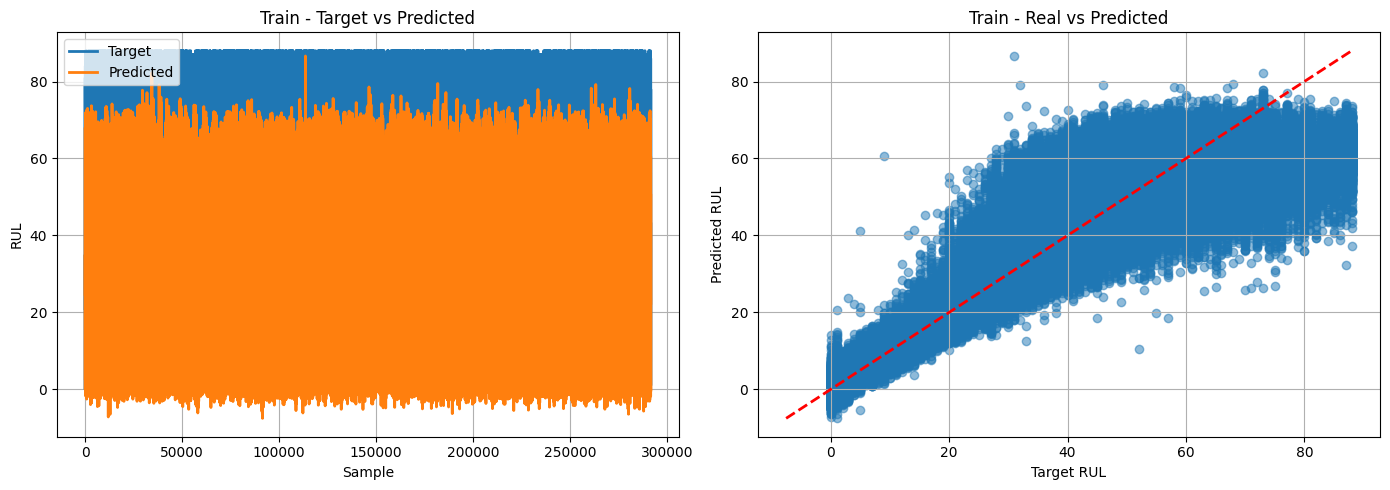

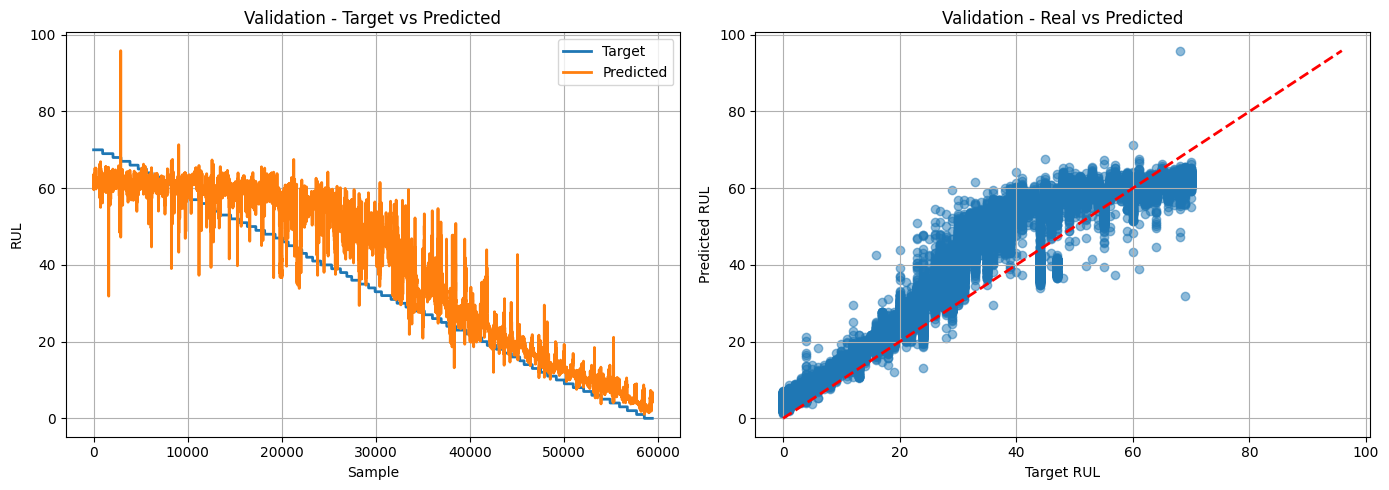

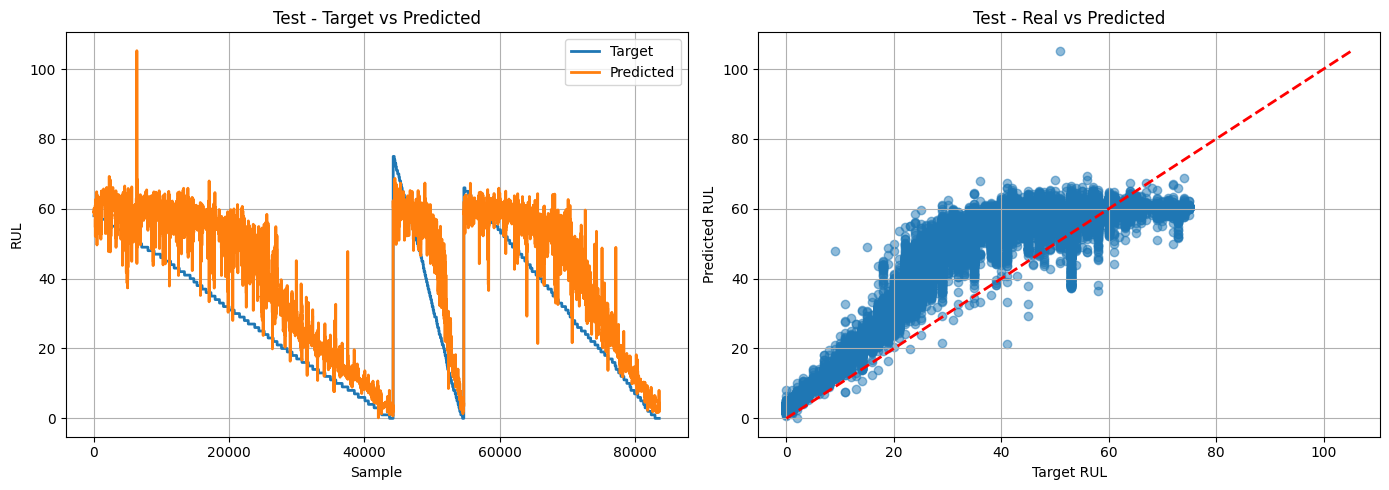

Configuration: lr: 0.0005, dropout: 0.2, num of channels : (64, 64, 64), kernel size: 4
cuda
cuda:0
Epoch 1/20 - LR: 0.000500 - Train Loss: 259.5176 - Train RMSE: 16.1096 - Train NASA mean: 4.1860 - Train NASA total: 1220213.17 - Val Loss: 43.1648 - Val RMSE: 6.5700 - Val NASA mean: 0.6865 - Val NASA total: 40764.56
Epoch 2/20 - LR: 0.000500 - Train Loss: 120.4511 - Train RMSE: 10.9750 - Train NASA mean: 1.6779 - Train NASA total: 489101.13 - Val Loss: 43.7892 - Val RMSE: 6.6173 - Val NASA mean: 0.7370 - Val NASA total: 43760.71
Epoch 3/20 - LR: 0.000500 - Train Loss: 104.1148 - Train RMSE: 10.2037 - Train NASA mean: 1.4516 - Train NASA total: 423135.83 - Val Loss: 37.1009 - Val RMSE: 6.0910 - Val NASA mean: 0.6517 - Val NASA total: 38694.86
Epoch 4/20 - LR: 0.000500 - Train Loss: 97.6677 - Train RMSE: 9.8827 - Train NASA mean: 1.3630 - Train NASA total: 397312.48 - Val Loss: 34.2228 - Val RMSE: 5.8500 - Val NASA mean: 0.6344 - Val NASA total: 37667.82
Epoch 5/20 - LR: 0.000500 - Train

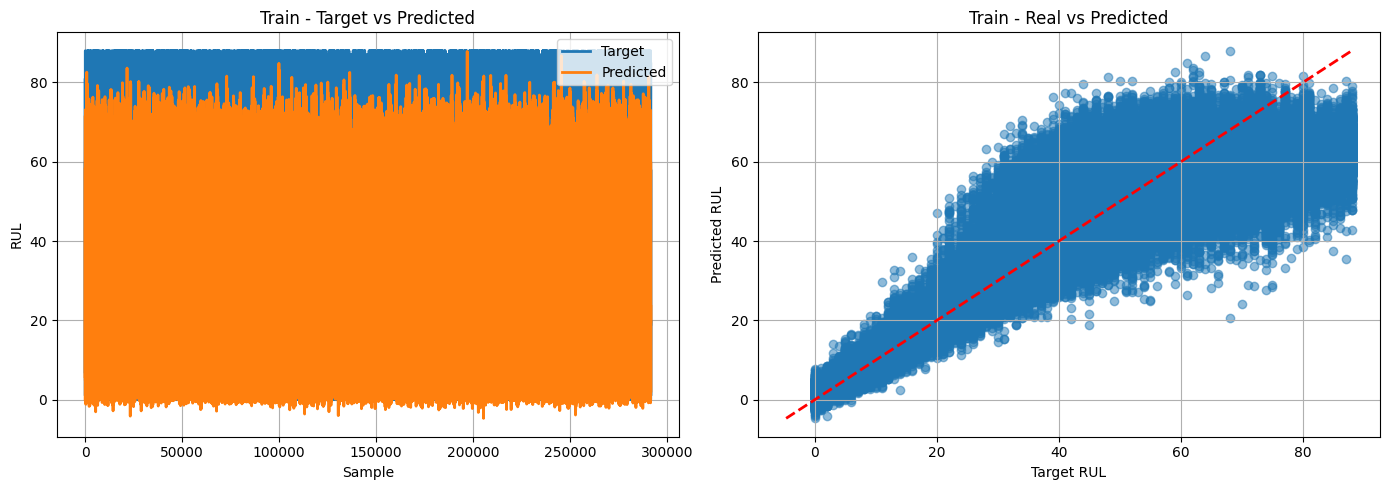

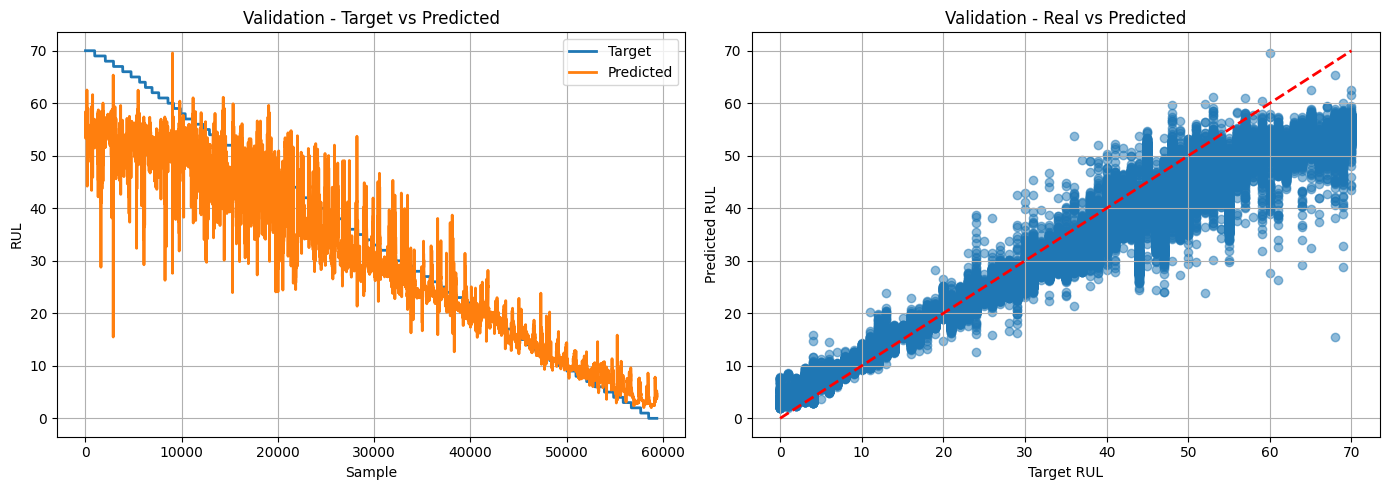

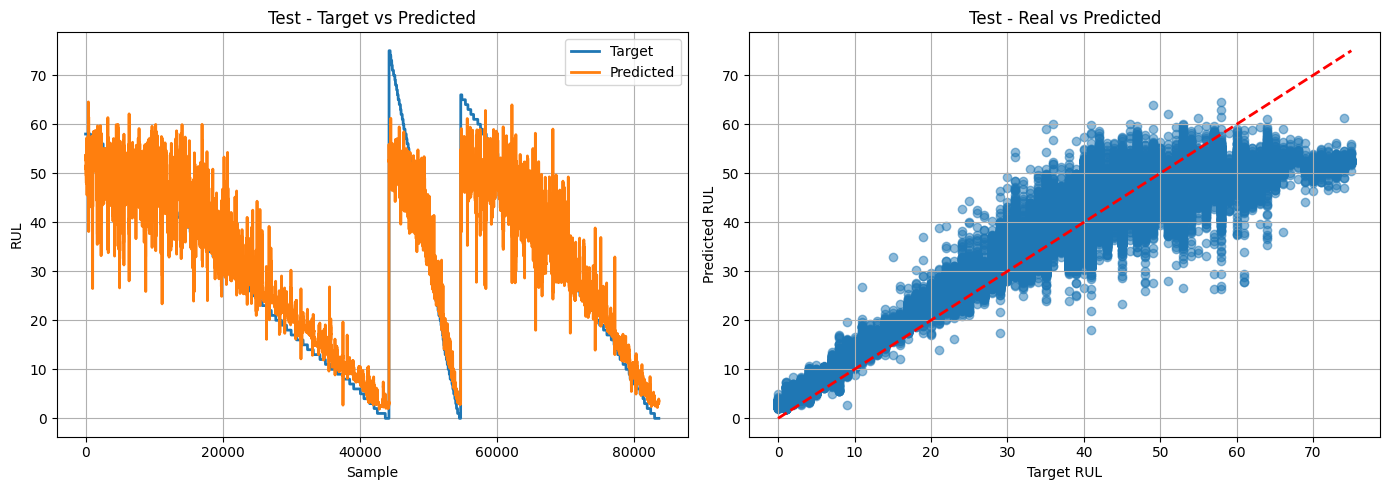

Configuration: lr: 0.0001, dropout: 0.3, num of channels : (64, 64, 128), kernel size: 5
cuda
cuda:0
Epoch 1/20 - LR: 0.000100 - Train Loss: 431.9500 - Train RMSE: 20.7834 - Train NASA mean: 7.2817 - Train NASA total: 2122634.11 - Val Loss: 921.0734 - Val RMSE: 30.3492 - Val NASA mean: 15.5753 - Val NASA total: 924832.72
Epoch 2/20 - LR: 0.000100 - Train Loss: 176.7211 - Train RMSE: 13.2936 - Train NASA mean: 2.5096 - Train NASA total: 731561.99 - Val Loss: 476.1476 - Val RMSE: 21.8208 - Val NASA mean: 6.2175 - Val NASA total: 369184.55
Epoch 3/20 - LR: 0.000100 - Train Loss: 127.1451 - Train RMSE: 11.2759 - Train NASA mean: 1.7780 - Train NASA total: 518280.97 - Val Loss: 482.8317 - Val RMSE: 21.9734 - Val NASA mean: 5.7698 - Val NASA total: 342598.24
Epoch 4/20 - LR: 0.000100 - Train Loss: 107.2795 - Train RMSE: 10.3576 - Train NASA mean: 1.4985 - Train NASA total: 436809.33 - Val Loss: 231.0268 - Val RMSE: 15.1996 - Val NASA mean: 2.5197 - Val NASA total: 149615.00
Epoch 5/20 - LR: 

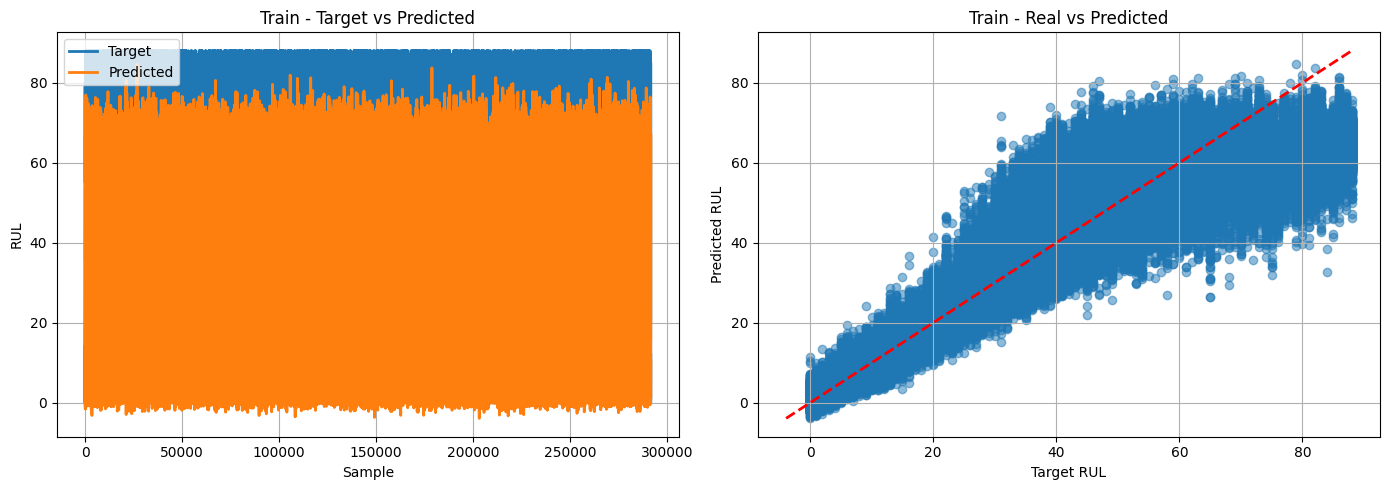

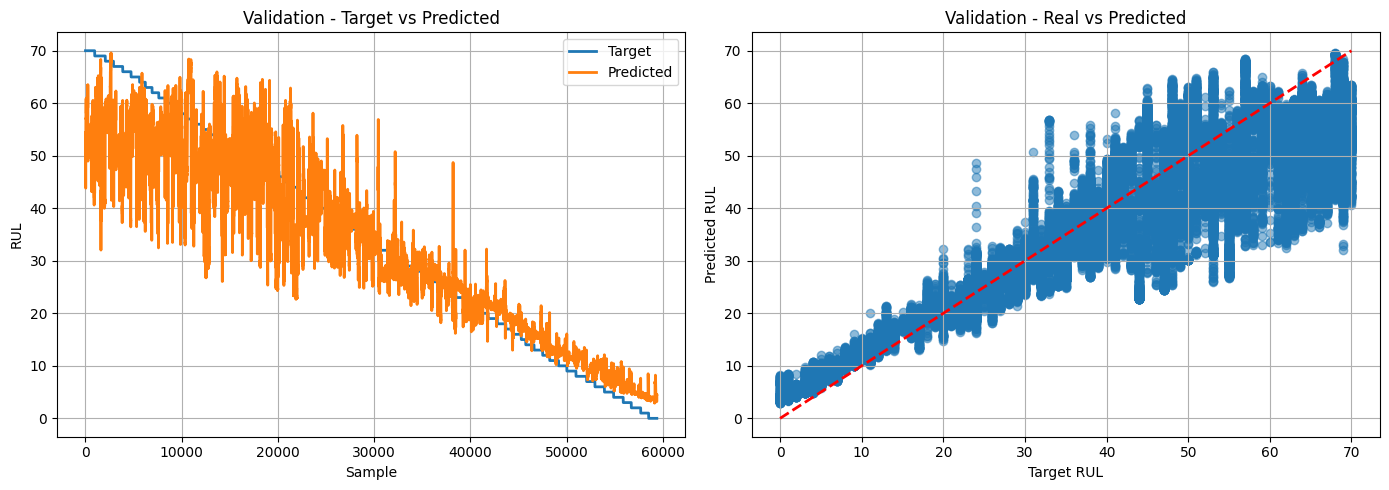

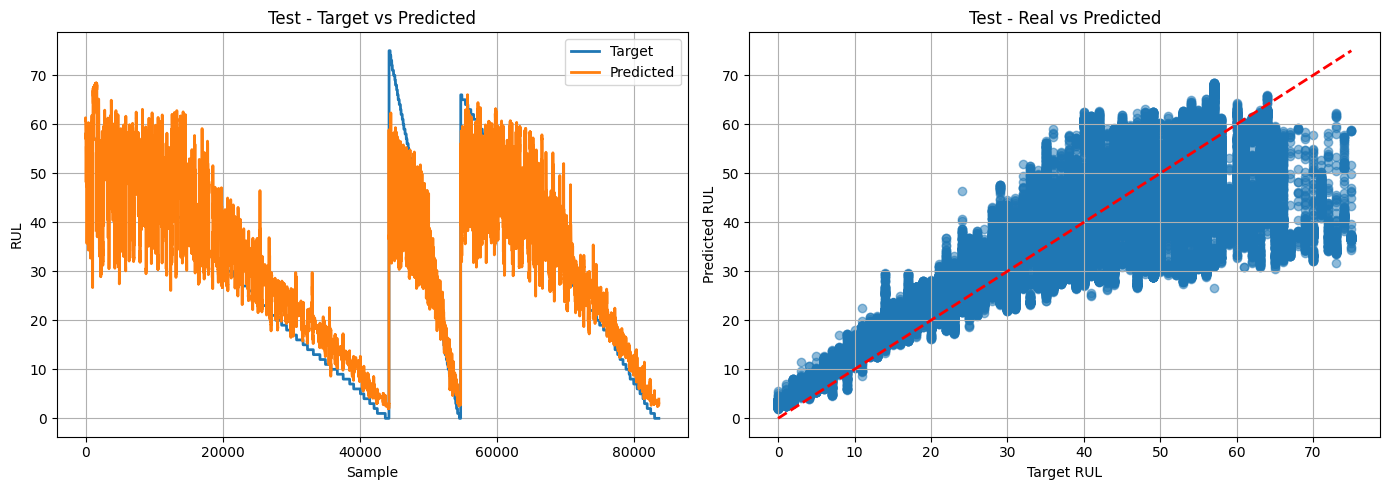

In [ ]:

search_space = [
    {"lr": 1e-3, "dropout": 0.1, "num_channels": (32, 64, 64), "kernel_size": 3},
    {"lr": 5e-4, "dropout": 0.2, "num_channels": (64, 64, 64), "kernel_size": 4},
    {"lr": 1e-4, "dropout": 0.3, "num_channels": (64, 64, 128), "kernel_size": 5},
]

best_val_rmse = float("inf")
best_config = None

for config in search_space:
    model = TCNRegressor(
    num_features=len(features),
    num_channels=config['num_channels'],
    kernel_size=config['kernel_size'],
    dropout=config['dropout']
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=1e-4
    )

    print(f'Configuration: lr: {config["lr"]}, dropout: {config["dropout"]}, num of channels : {config["num_channels"]}, kernel size: {config["kernel_size"]}')

    trained_model, train_preds, train_targets, val_preds, val_targets = train(
    criterion, optimizer, train_loader, val_loader, model, num_epochs=20
    )

    test_loss, test_rmse, test_nasa, test_preds, test_targets = test(trained_model, test_loader, criterion)
    # evaluate val RMSE here and compare
    plot_predictions(train_targets, train_preds, split_name="Train")
    plot_predictions(val_targets, val_preds, split_name="Validation")
    plot_predictions(test_targets, test_preds, split_name="Test")

## **Optuna parameters tunning**

#### **physical sensors only**

In [ ]:
!pip install optuna

In [ ]:
import optuna


def objective(trial):

    # Hyperparameters to tune
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    num_channels = trial.suggest_categorical(
        "num_channels",
        [
            (32, 64, 64),
            (64, 64, 64),
            (64, 64, 128),
        ],
    )

    kernel_size = trial.suggest_categorical("kernel_size", [3, 4, 5])

    weight_decay = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-3,
        log=True,
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128],
    )

    num_epochs = trial.suggest_categorical(
        "num_epochs",
        [20, 40, 60],
    )

    window_size = trial.suggest_categorical(
        "window_size",
        [50, 100, 500],
    )

    stride = trial.suggest_categorical(
        "stride",
        [15, 20, 30, 40, 150, 200],
    )

    # Only allow valid stride/window combinations
    valid_strides = {
        50: [15, 20],
        100: [30, 40],
        500: [150, 200],
    }

    if stride not in valid_strides[window_size]:
        raise optuna.TrialPruned()

    # -----------------------------
    # Create datasets
    # -----------------------------

    train_engine_df = X_train_scaled_df[X_train_scaled_df["unit"] != 18]
    val_engine_df = X_train_scaled_df[X_train_scaled_df["unit"] == 18]

    X_windows_train, Y_windows_train = create_windows(
        train_engine_df,
        features,
        window_size=window_size,
        stride=stride,
    )

    X_windows_val, Y_windows_val = create_windows(
        val_engine_df,
        features,
        window_size=window_size,
        stride=stride,
    )

    X_windows_test, Y_windows_test = create_windows(
        X_test_scaled_df,
        features,
        window_size=window_size,
        stride=stride,
    )

    dataset_train = CMAPSS(X_windows_train, Y_windows_train)
    dataset_val = CMAPSS(X_windows_val, Y_windows_val)
    dataset_test = CMAPSS(X_windows_test, Y_windows_test)

    train_loader = DataLoader(
        dataset_train,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        dataset_val,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        dataset_test,
        batch_size=batch_size,
        shuffle=False,
    )

    # -----------------------------
    # Model
    # -----------------------------

    model = TCNRegressor(
        num_features=len(features),
        num_channels=num_channels,
        kernel_size=kernel_size,
        dropout=dropout,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    criterion = torch.nn.MSELoss()

    # -----------------------------
    # Training
    # -----------------------------

    model, train_preds, train_targets, val_preds, val_targets = train(
        criterion=criterion,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        model=model,
        num_epochs=num_epochs,
    )

    # -----------------------------
    # Evaluation
    # -----------------------------

    test_loss, test_rmse, test_nasa, test_preds, test_targets = test(
        model,
        test_loader,
        criterion,
    )

   
    return test_rmse


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print(study.best_params)
print(study.best_value)

[I 2026-07-13 07:13:31,580] A new study created in memory with name: no-name-0775693e-62ec-42c6-b180-600f0b758b92
C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 128) which is of type tuple.
  num_channels = trial.suggest_categorical(
[I 2026-07-1

cuda
cuda:0
Epoch 1/60 - LR: 0.000042 - Train Loss: 568.7174 - Train RMSE: 23.8478 - Train NASA mean: 10.6967 - Train NASA total: 2338582.38 - Val Loss: 513.4977 - Val RMSE: 22.6605 - Val NASA mean: 6.5036 - Val NASA total: 289630.90
Epoch 2/60 - LR: 0.000042 - Train Loss: 450.0477 - Train RMSE: 21.2143 - Train NASA mean: 7.4570 - Train NASA total: 1630307.63 - Val Loss: 586.0753 - Val RMSE: 24.2090 - Val NASA mean: 7.7508 - Val NASA total: 345175.18
Epoch 3/60 - LR: 0.000042 - Train Loss: 228.4271 - Train RMSE: 15.1138 - Train NASA mean: 3.8357 - Train NASA total: 838593.05 - Val Loss: 383.6583 - Val RMSE: 19.5872 - Val NASA mean: 4.3233 - Val NASA total: 192532.20
Epoch 4/60 - LR: 0.000042 - Train Loss: 166.1063 - Train RMSE: 12.8882 - Train NASA mean: 2.5070 - Train NASA total: 548089.91 - Val Loss: 285.4593 - Val RMSE: 16.8955 - Val NASA mean: 2.9889 - Val NASA total: 133106.21
Epoch 5/60 - LR: 0.000042 - Train Loss: 143.5299 - Train RMSE: 11.9804 - Train NASA mean: 2.0794 - Train 

[I 2026-07-13 07:19:14,014] Trial 1 finished with value: 11.718955993652344 and parameters: {'lr': 4.239002158867088e-05, 'dropout': 0.4079990085756303, 'num_channels': (64, 64, 64), 'kernel_size': 4, 'weight_decay': 0.00010619982022306769, 'batch_size': 32, 'num_epochs': 60, 'window_size': 50, 'stride': 20}. Best is trial 1 with value: 11.718955993652344.
C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460

cuda
cuda:0
Epoch 1/60 - LR: 0.000010 - Train Loss: 695.5537 - Train RMSE: 26.3734 - Train NASA mean: 15.7697 - Train NASA total: 3447682.22 - Val Loss: 507.9498 - Val RMSE: 22.5377 - Val NASA mean: 6.5008 - Val NASA total: 289505.40
Epoch 2/60 - LR: 0.000010 - Train Loss: 570.9840 - Train RMSE: 23.8953 - Train NASA mean: 10.8429 - Train NASA total: 2370553.84 - Val Loss: 535.9447 - Val RMSE: 23.1505 - Val NASA mean: 6.8565 - Val NASA total: 305347.00
Epoch 3/60 - LR: 0.000010 - Train Loss: 556.5867 - Train RMSE: 23.5921 - Train NASA mean: 10.2732 - Train NASA total: 2246000.67 - Val Loss: 538.2881 - Val RMSE: 23.2010 - Val NASA mean: 6.8859 - Val NASA total: 306656.38
Epoch 4/60 - LR: 0.000010 - Train Loss: 548.1834 - Train RMSE: 23.4133 - Train NASA mean: 9.9176 - Train NASA total: 2168257.77 - Val Loss: 556.6888 - Val RMSE: 23.5943 - Val NASA mean: 7.1793 - Val NASA total: 319721.68
Epoch 5/60 - LR: 0.000010 - Train Loss: 540.5431 - Train RMSE: 23.2496 - Train NASA mean: 9.6641 - Tr

[I 2026-07-13 07:22:39,392] Trial 11 finished with value: 20.46919822692871 and parameters: {'lr': 1.010776747685202e-05, 'dropout': 0.4736657684835821, 'num_channels': (64, 64, 64), 'kernel_size': 4, 'weight_decay': 5.9300382702830226e-05, 'batch_size': 32, 'num_epochs': 60, 'window_size': 50, 'stride': 20}. Best is trial 1 with value: 11.718955993652344.


...

Test Loss: 140.1109 - Test RMSE: 11.8368 - Test NASA mean: 1.5440 - Test NASA total: 129035.91


C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 64) which is of type tuple.
  num_channels = trial.suggest_categorical(
C:\Users\Student\AppData\Local\Temp\ipykernel_10956\1515460968.py:13: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 64, 128) which is of type tuple.
  num_channels = trial.suggest_categorical(


cuda
cuda:0
Epoch 1/20 - LR: 0.000302 - Train Loss: 399.1321 - Train RMSE: 19.9783 - Train NASA mean: 6.6216 - Train NASA total: 723798.94 - Val Loss: 91.1082 - Val RMSE: 9.5451 - Val NASA mean: 1.3425 - Val NASA total: 29891.68
Epoch 2/20 - LR: 0.000302 - Train Loss: 157.6403 - Train RMSE: 12.5555 - Train NASA mean: 2.2139 - Train NASA total: 242004.13 - Val Loss: 134.8785 - Val RMSE: 11.6137 - Val NASA mean: 1.4242 - Val NASA total: 31711.48
Epoch 3/20 - LR: 0.000302 - Train Loss: 121.3506 - Train RMSE: 11.0159 - Train NASA mean: 1.6893 - Train NASA total: 184659.03 - Val Loss: 73.2879 - Val RMSE: 8.5608 - Val NASA mean: 0.9621 - Val NASA total: 21421.22
Epoch 4/20 - LR: 0.000302 - Train Loss: 108.0895 - Train RMSE: 10.3966 - Train NASA mean: 1.5095 - Train NASA total: 164997.66 - Val Loss: 50.0167 - Val RMSE: 7.0722 - Val NASA mean: 0.6685 - Val NASA total: 14884.86
Epoch 5/20 - LR: 0.000302 - Train Loss: 100.7591 - Train RMSE: 10.0379 - Train NASA mean: 1.4082 - Train NASA total: 1

[I 2026-07-13 09:27:08,708] Trial 29 finished with value: 6.69066047668457 and parameters: {'lr': 0.0003023010376141941, 'dropout': 0.1027821692936946, 'num_channels': (64, 64, 128), 'kernel_size': 3, 'weight_decay': 1.3305150970369112e-06, 'batch_size': 32, 'num_epochs': 20, 'window_size': 100, 'stride': 40}. Best is trial 14 with value: 5.446829795837402.


Test Loss: 44.7649 - Test RMSE: 6.6907 - Test NASA mean: 0.7026 - Test NASA total: 22016.41
{'lr': 0.0002560338611414976, 'dropout': 0.499366333418993, 'num_channels': (64, 64, 128), 'kernel_size': 4, 'weight_decay': 0.00041964166848323296, 'batch_size': 32, 'num_epochs': 60, 'window_size': 50, 'stride': 15}
5.446829795837402


### **Best hyperparameters from Optuna**

In [8]:
best_params = study.best_params
print(best_params)
print("Best validation RMSE:", study.best_value)

print("=" * 100)
print("=" * 100)

top3 = sorted(
    [t for t in study.trials if t.value is not None],
    key=lambda t: t.value
)[:3]

# Print best three trials
for i, trial in enumerate(top3, 1):
    print(f"Top {i}: Validation RMSE = {trial.value:.4f}")
    print(trial.params)
    print()

# Best hyperparameters
best_window_size = best_params["window_size"]
best_stride = best_params["stride"]
best_num_channels = best_params["num_channels"]
best_kernel_size = best_params["kernel_size"]
best_dropout = best_params["dropout"]
best_weight_decay = best_params["weight_decay"]
best_batch_size = best_params["batch_size"]
best_lr = best_params["lr"]
best_num_epochs = best_params["num_epochs"]

print(
    f"best_window_size: {best_window_size}\n"
    f"best_stride: {best_stride}\n"
    f"best_num_channels: {best_num_channels}\n"
    f"best_kernel_size: {best_kernel_size}\n"
    f"best_dropout: {best_dropout}\n"
    f"best_weight_decay: {best_weight_decay}\n"
    f"best_batch_size: {best_batch_size}\n"
    f"best_lr: {best_lr}\n"
    f"best_num_epochs: {best_num_epochs}"
)

{'lr': 0.0002560338611414976, 'dropout': 0.499366333418993, 'num_channels': (64, 64, 128), 'kernel_size': 4, 'weight_decay': 0.00041964166848323296, 'batch_size': 32, 'num_epochs': 60, 'window_size': 50, 'stride': 15}
Best validation RMSE: 5.446829795837402
Top 1: Validation RMSE = 5.4468
{'lr': 0.0002560338611414976, 'dropout': 0.499366333418993, 'num_channels': (64, 64, 128), 'kernel_size': 4, 'weight_decay': 0.00041964166848323296, 'batch_size': 32, 'num_epochs': 60, 'window_size': 50, 'stride': 15}

Top 2: Validation RMSE = 5.9475
{'lr': 0.00032155330907580106, 'dropout': 0.4434243727629388, 'num_channels': (64, 64, 128), 'kernel_size': 4, 'weight_decay': 0.0009180173125533799, 'batch_size': 32, 'num_epochs': 20, 'window_size': 50, 'stride': 15}

Top 3: Validation RMSE = 6.6907
{'lr': 0.0003023010376141941, 'dropout': 0.1027821692936946, 'num_channels': (64, 64, 128), 'kernel_size': 3, 'weight_decay': 1.3305150970369112e-06, 'batch_size': 32, 'num_epochs': 20, 'window_size': 100, '

## **Retrain with the best hyperparameters from Optuna**

Shape of train_engine_df: (4372728, 21) and engine units: [ 2  5 10 16 20]
Shape of val_engine_df: (890719, 21) and engine units: [18]
Shape of X_test_scaled_df: (1253743, 21) and engine units: [11 14 15]
X train normalized windows shape: (291501, 50, 18) 
 Y train windows  shape: (291501,)
X val windows shape: (59378, 50, 18) 
 Y val windows  shape: (59378,)
X test windows shape: (83574, 50, 18) 
 Y test windows  shape: (83574,)
cuda
cuda:0
Epoch 1/40 - LR: 0.000256 - Train Loss: 317.8957 - Train RMSE: 17.8296 - Train NASA mean: 5.2567 - Train NASA total: 1532340.62 - Val Loss: 173.9299 - Val RMSE: 13.1882 - Val NASA mean: 1.8270 - Val NASA total: 108486.55
Epoch 2/40 - LR: 0.000256 - Train Loss: 131.0955 - Train RMSE: 11.4497 - Train NASA mean: 1.8308 - Train NASA total: 533690.39 - Val Loss: 39.6884 - Val RMSE: 6.2999 - Val NASA mean: 0.6166 - Val NASA total: 36610.82
Epoch 3/40 - LR: 0.000256 - Train Loss: 108.3245 - Train RMSE: 10.4079 - Train NASA mean: 1.5126 - Train NASA total:

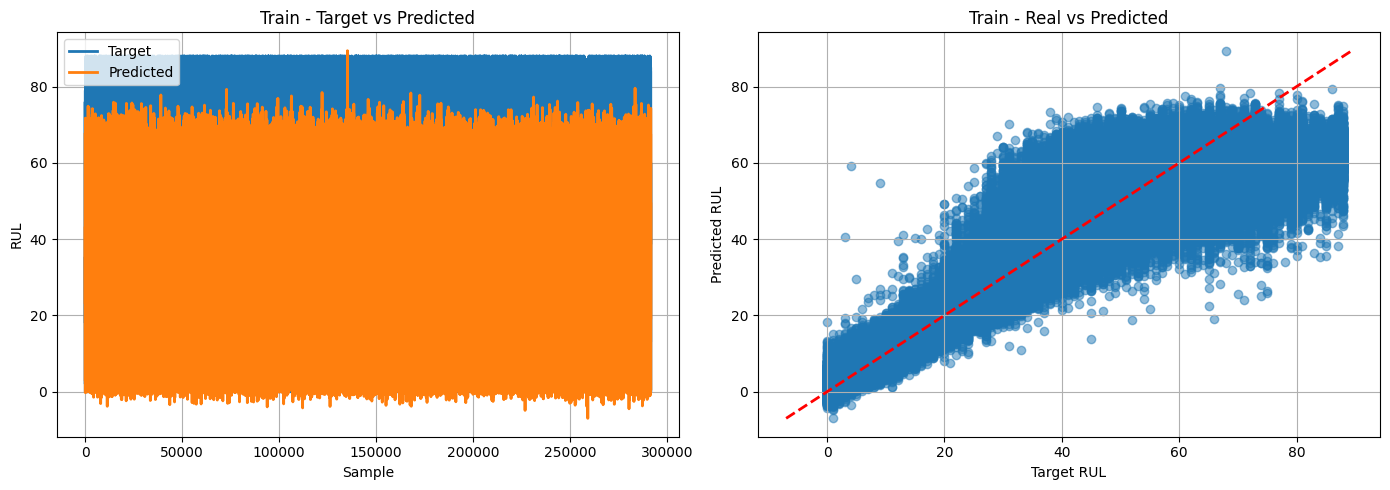

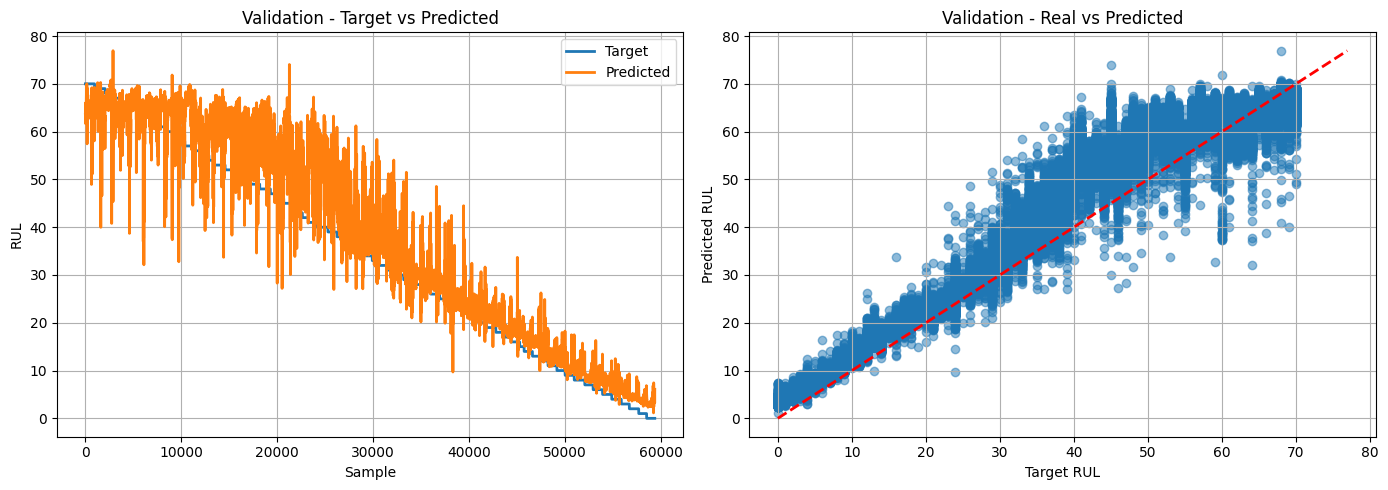

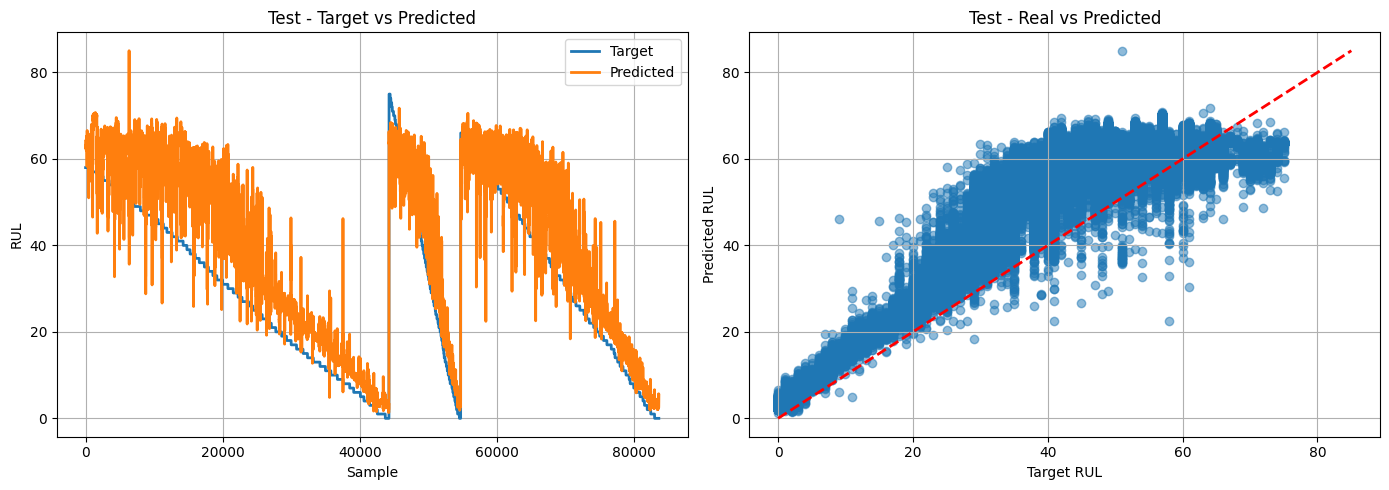

In [ ]:
train_engine_df = X_train_scaled_df[X_train_scaled_df['unit'] != 18]
val_engine_df   = X_train_scaled_df[X_train_scaled_df['unit'] == 18]

print(f"Shape of train_engine_df: {train_engine_df.shape} and engine units: {train_engine_df['unit'].unique()}")
print(f"Shape of val_engine_df: {val_engine_df.shape} and engine units: {val_engine_df['unit'].unique()}")
print(f"Shape of X_test_scaled_df: {X_test_scaled_df.shape} and engine units: {X_test_scaled_df['unit'].unique()}")

X_windows_train, Y_windows_train = create_windows(train_engine_df, features, window_size=best_window_size, stride=best_stride)
X_windows_val, Y_windows_val     = create_windows(val_engine_df, features, window_size=best_window_size, stride=best_stride)
X_windows_test, Y_windows_test = create_windows(X_test_scaled_df, features, window_size=best_window_size, stride=best_stride)

print("X train normalized windows shape:",X_windows_train.shape,"\n Y train windows  shape:" , Y_windows_train.shape) 
print("X val windows shape:",X_windows_val.shape,"\n Y val windows  shape:" , Y_windows_val.shape) # engine (18) for validating
print("X test windows shape:",X_windows_test.shape,"\n Y test windows  shape:" , Y_windows_test.shape) 

dataset_train = CMAPSS(X_windows_train, Y_windows_train)
dataset_val   = CMAPSS(X_windows_val, Y_windows_val)
dataset_test  = CMAPSS(X_windows_test, Y_windows_test)

train_loader = DataLoader(dataset_train, batch_size=best_batch_size, shuffle=True)
val_loader   = DataLoader(dataset_val, batch_size=best_batch_size, shuffle=False)
test_loader  = DataLoader(dataset_test, batch_size=best_batch_size, shuffle=False)

model = TCNRegressor(
    num_features=len(features),
    num_channels=best_num_channels,
    kernel_size=best_kernel_size,
    dropout=best_dropout,
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_lr,
    weight_decay=best_weight_decay
)

criterion = torch.nn.MSELoss()

model, train_preds, train_targets, val_preds, val_targets = train(
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    model=model,
    num_epochs=40 
)

test_loss, test_rmse, test_nasa, test_preds, test_targets = test(model, test_loader, criterion) 

plot_predictions(train_targets, train_preds, split_name="Train")
plot_predictions(val_targets, val_preds, split_name="Validation")
plot_predictions(test_targets, test_preds, split_name="Test")